In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [4]:
from google.colab import files

uploaded = files.upload()

Saving data.csv to data (1).csv


In [5]:
print(os.listdir())

['.config', 'data (1).csv', 'data.csv', 'sample_data']


In [6]:
df = pd.read_csv('data.csv')

In [7]:
print("\nFIRST 5 ROWS")
print(df.head())


FIRST 5 ROWS
          Income  Age  Dependents     Occupation City_Tier          Rent  \
0   44637.249636   49           0  Self_Employed    Tier_1  13391.174891   
1   26858.596592   34           2        Retired    Tier_2   5371.719318   
2   50367.605084   35           1        Student    Tier_3   7555.140763   
3  101455.600247   21           0  Self_Employed    Tier_3  15218.340037   
4   24875.283548   52           4   Professional    Tier_2   4975.056710   

   Loan_Repayment    Insurance     Groceries    Transport  ...  \
0        0.000000  2206.490129   6658.768341  2636.970696  ...   
1        0.000000   869.522617   2818.444460  1543.018778  ...   
2     4612.103386  2201.800050   6313.222081  3221.396403  ...   
3     6809.441427  4889.418087  14690.149363  7106.130005  ...   
4     3112.609398   635.907170   3034.329665  1276.155163  ...   

   Desired_Savings  Disposable_Income  Potential_Savings_Groceries  \
0      6200.537192       11265.627707                  1685.69

In [8]:
print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns.tolist())

print("\nDATASET INFO")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())


DATASET SHAPE
(20000, 27)

COLUMN NAMES
['Income', 'Age', 'Dependents', 'Occupation', 'City_Tier', 'Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport', 'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare', 'Education', 'Miscellaneous', 'Desired_Savings_Percentage', 'Desired_Savings', 'Disposable_Income', 'Potential_Savings_Groceries', 'Potential_Savings_Transport', 'Potential_Savings_Eating_Out', 'Potential_Savings_Entertainment', 'Potential_Savings_Utilities', 'Potential_Savings_Healthcare', 'Potential_Savings_Education', 'Potential_Savings_Miscellaneous']

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Income                           20000 non-null  float64
 1   Age                              20000 non-null  int64  
 2   Dependents                       20000 non-

In [9]:
df = df.drop_duplicates()

# REMOVE NULL VALUES
df = df.dropna()

print("\nDATA CLEANING COMPLETED")


DATA CLEANING COMPLETED


In [11]:
sns.set_style("whitegrid")

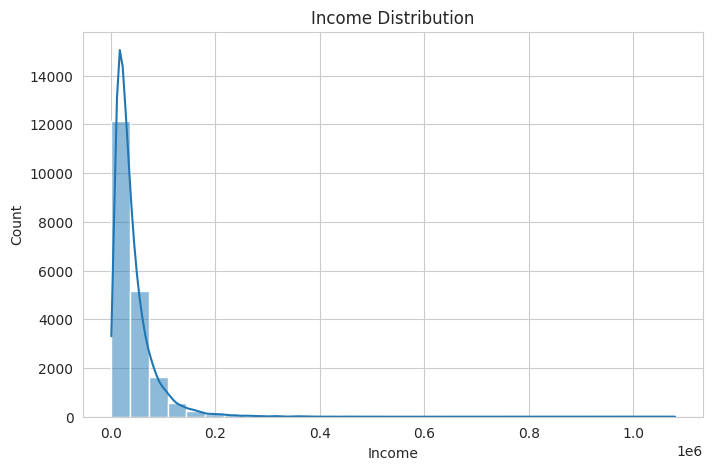

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['Income'], bins=30, kde=True)

plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Count')

plt.show()

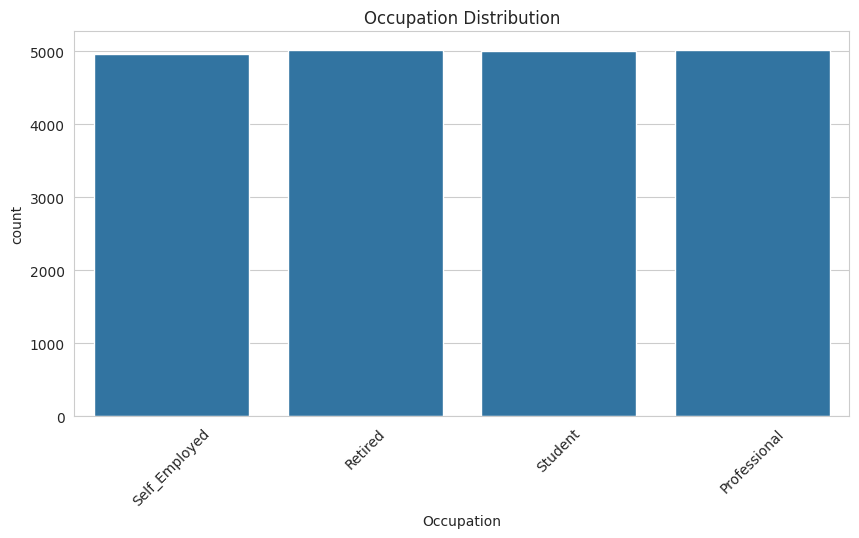

In [13]:
plt.figure(figsize=(10,5))

sns.countplot(x='Occupation', data=df)

plt.title('Occupation Distribution')

plt.xticks(rotation=45)

plt.show()

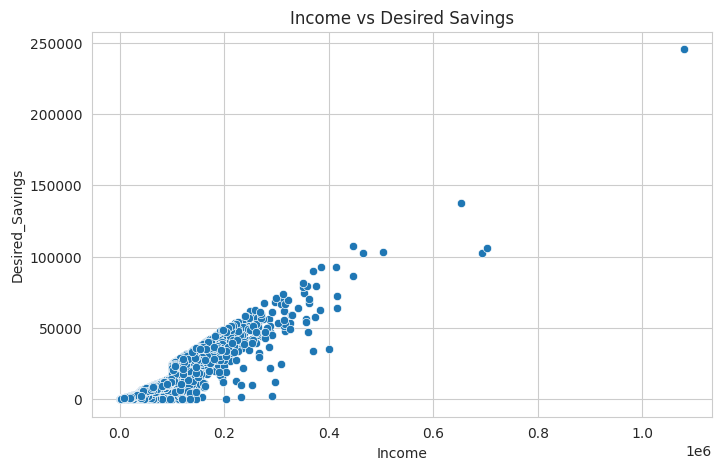

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Income',
    y='Desired_Savings',
    data=df
)

plt.title('Income vs Desired Savings')

plt.show()

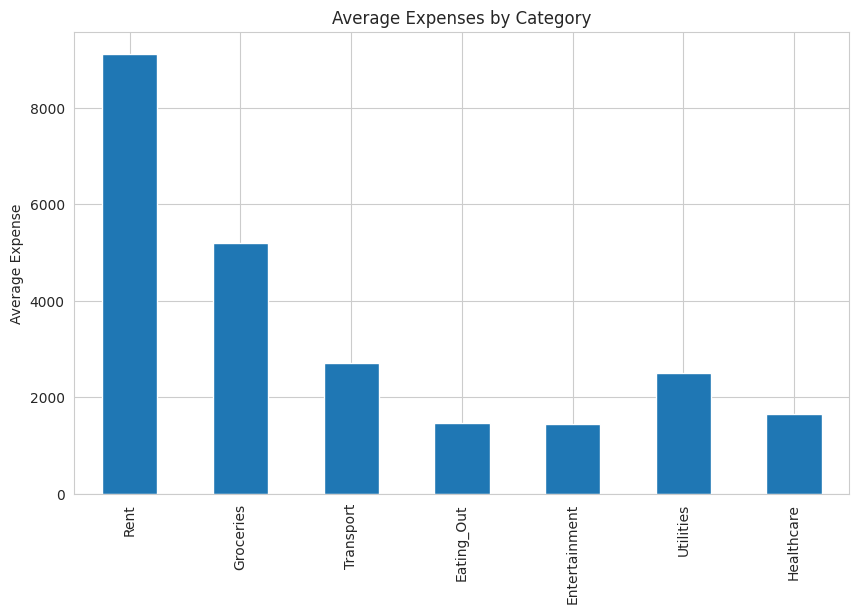

In [15]:
expenses = [
    'Rent',
    'Groceries',
    'Transport',
    'Eating_Out',
    'Entertainment',
    'Utilities',
    'Healthcare'
]

expense_means = df[expenses].mean()

plt.figure(figsize=(10,6))

expense_means.plot(kind='bar')

plt.title('Average Expenses by Category')
plt.ylabel('Average Expense')

plt.show()

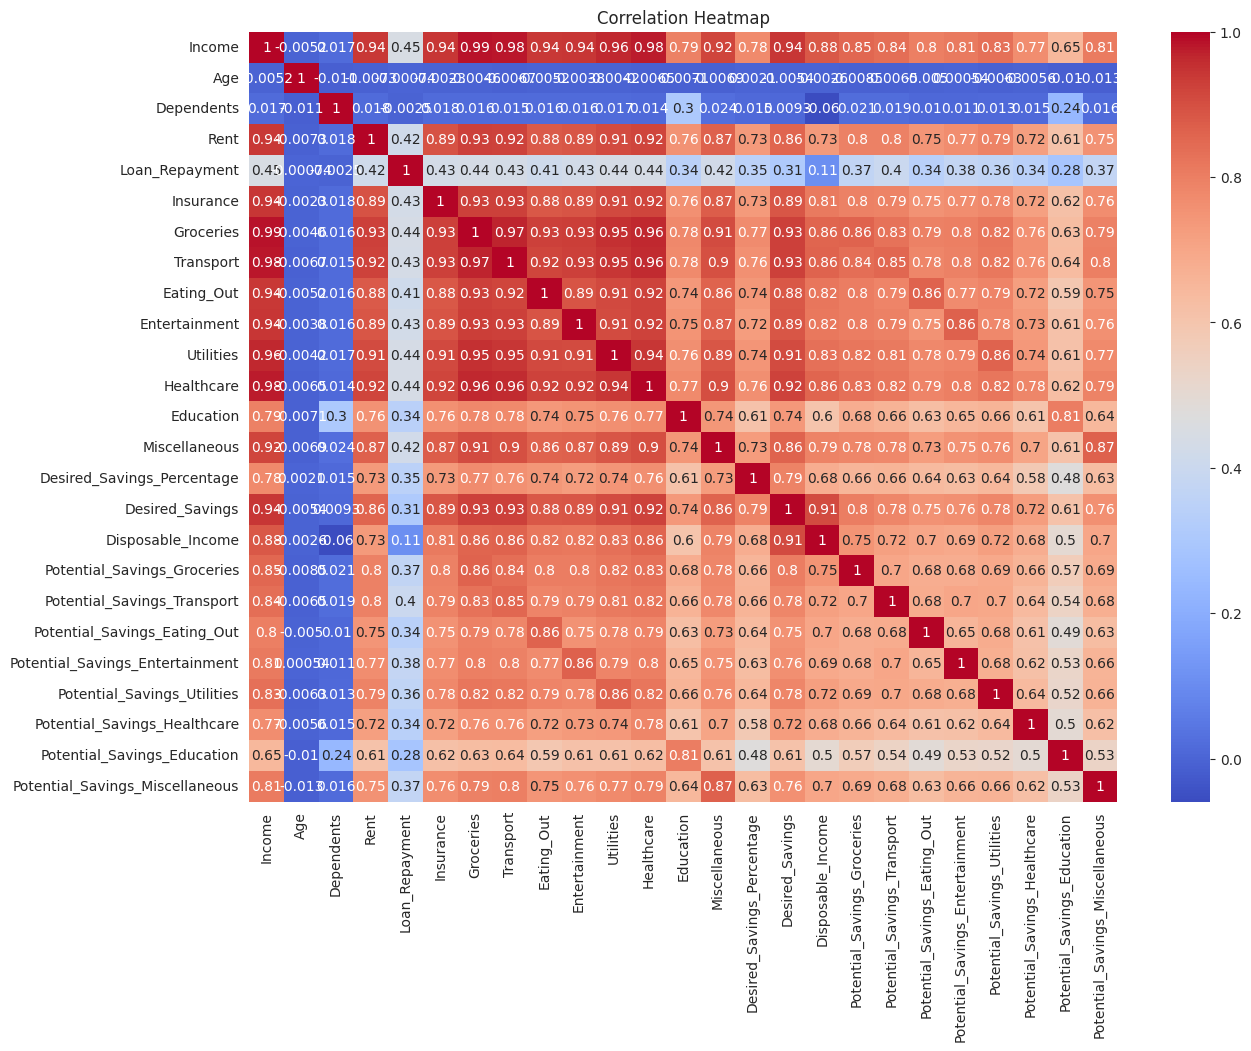

In [16]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [17]:
X = df[[
    'Income',
    'Age',
    'Rent',
    'Groceries',
    'Transport',
    'Entertainment',
    'Utilities'
]]

# TARGET

y = df['Desired_Savings']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
model = LinearRegression()

model.fit(X_train, y_train)

print("\nMODEL TRAINED SUCCESSFULLY")


MODEL TRAINED SUCCESSFULLY


In [20]:
y_pred = model.predict(X_test)

In [21]:
print("\nMODEL PERFORMANCE")

print("\nR2 SCORE")
print(r2_score(y_test, y_pred))

print("\nMEAN ABSOLUTE ERROR")
print(mean_absolute_error(y_test, y_pred))


MODEL PERFORMANCE

R2 SCORE
0.906976374339196

MEAN ABSOLUTE ERROR
1450.8661295059844


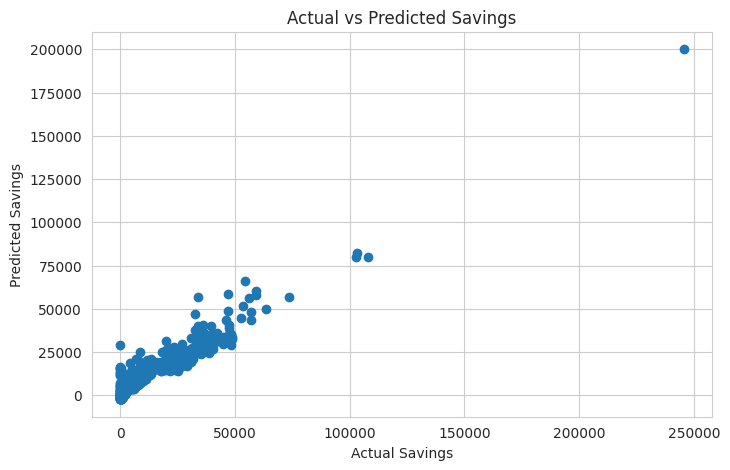

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Savings")
plt.ylabel("Predicted Savings")

plt.title("Actual vs Predicted Savings")

plt.show()

In [23]:
sample_data = [[
    50000,   # Income
    25,      # Age
    10000,   # Rent
    5000,    # Groceries
    2000,    # Transport
    3000,    # Entertainment
    1500     # Utilities
]]

prediction = model.predict(sample_data)

print("\nPREDICTED SAVINGS")
print(prediction[0])


PREDICTED SAVINGS
7178.070593375442


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [24]:
print("\nPROJECT COMPLETED SUCCESSFULLY")

print("""
CONCLUSION

1. Income strongly affects savings.
2. Higher expenses reduce savings.
3. Expense tracking helps budgeting.
4. Machine Learning can predict savings patterns.
5. Data visualization helps understand spending behavior.
""")


PROJECT COMPLETED SUCCESSFULLY

CONCLUSION

1. Income strongly affects savings.
2. Higher expenses reduce savings.
3. Expense tracking helps budgeting.
4. Machine Learning can predict savings patterns.
5. Data visualization helps understand spending behavior.

